<a href="https://colab.research.google.com/github/Chandu1722/ML/blob/main/Kaggle/HeartDisease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import pandas as pd

In [23]:
train=pd.read_csv('train.csv')
train.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [24]:
test=pd.read_csv('test.csv')


In [25]:
train['Heart Disease']=train['Heart Disease'].str.strip().map({'Presence':1,'Absence':0})
train

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,1
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,0
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,0
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,0
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,629995,56,0,1,110,226,0,0,132,0,0.0,1,0,7,0
629996,629996,54,1,4,128,249,1,2,150,0,0.0,2,0,3,0
629997,629997,67,1,4,130,275,0,0,149,0,0.0,1,2,7,1
629998,629998,52,1,4,140,199,0,2,157,0,0.0,1,0,6,1


In [40]:
corr = train.corr()['Heart Disease'].abs().sort_values(ascending=False)
print(corr)


Heart Disease              1.000000
Thallium                   0.605776
Chest pain type            0.460684
Exercise angina            0.441864
Max HR                     0.440985
Number of vessels fluro    0.438604
ST depression              0.430641
Slope of ST                0.415050
Sex                        0.342446
EKG results                0.218961
Age                        0.212091
Cholesterol                0.082753
FBS over 120               0.033570
BP                         0.005181
id                         0.000209
Name: Heart Disease, dtype: float64


In [26]:
cols=[
 'Age',
 'Sex',
 'Chest pain type',
 'BP',
 'Cholesterol',
 'FBS over 120',
 'EKG results',
 'Max HR',
 'Exercise angina',
 'ST depression',
 'Slope of ST',
 'Number of vessels fluro',
 'Thallium']

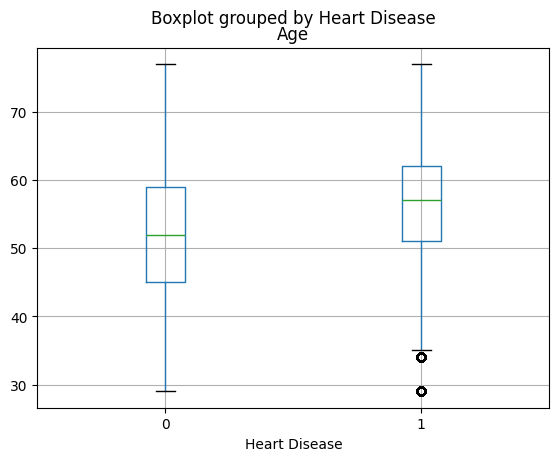

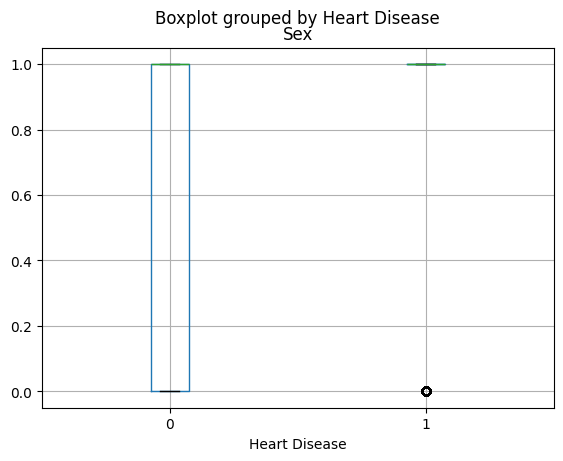

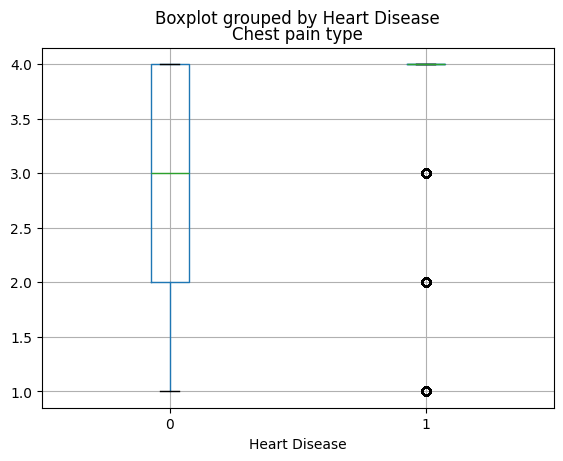

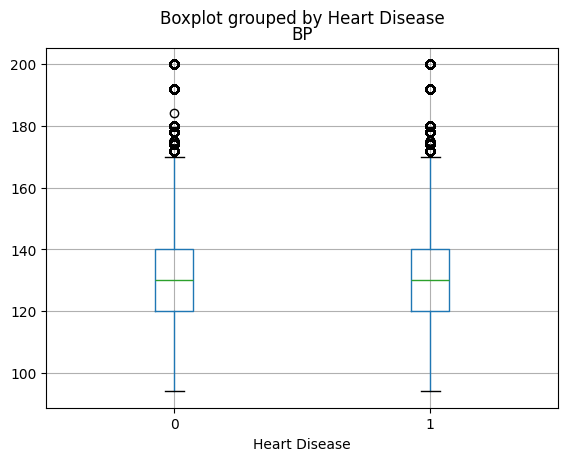

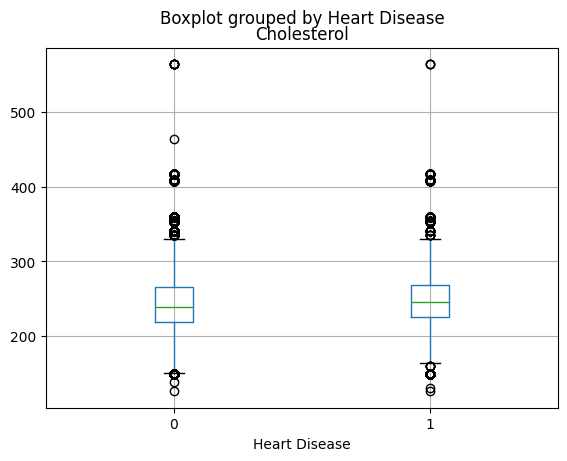

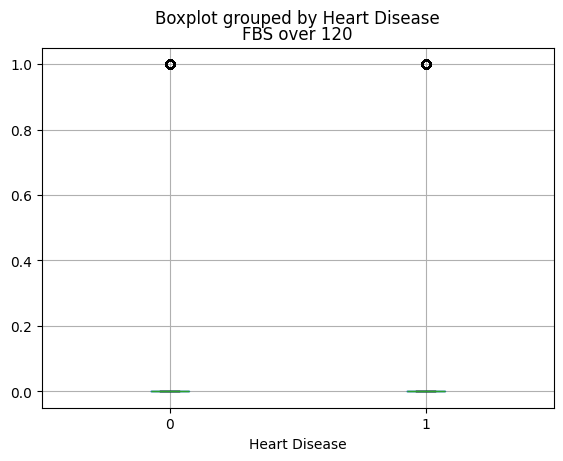

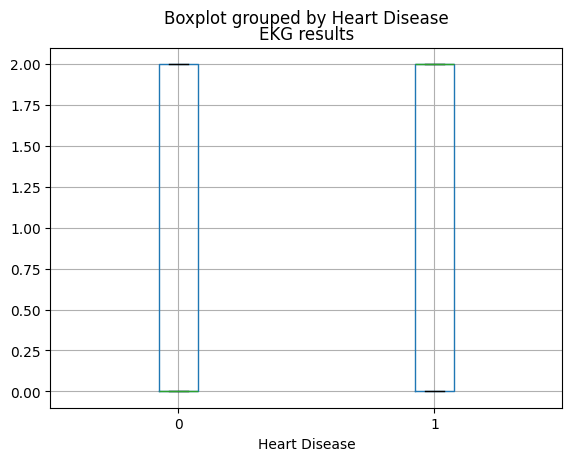

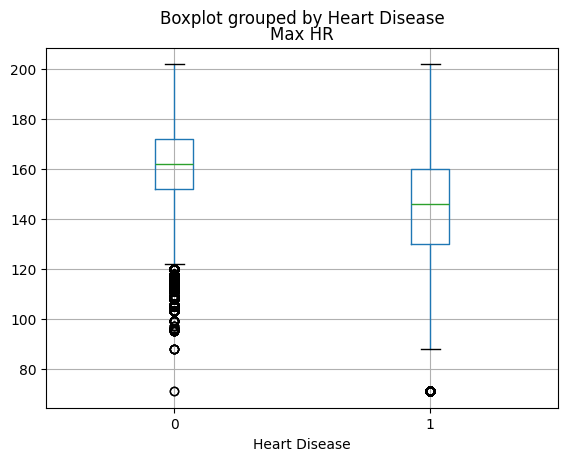

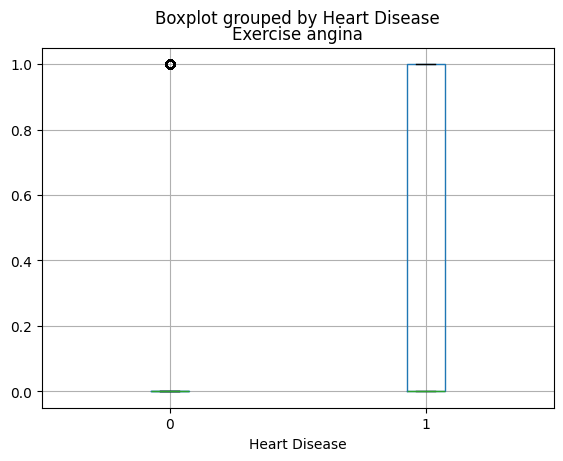

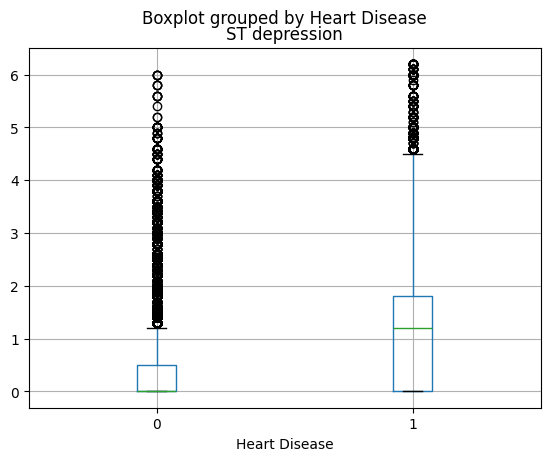

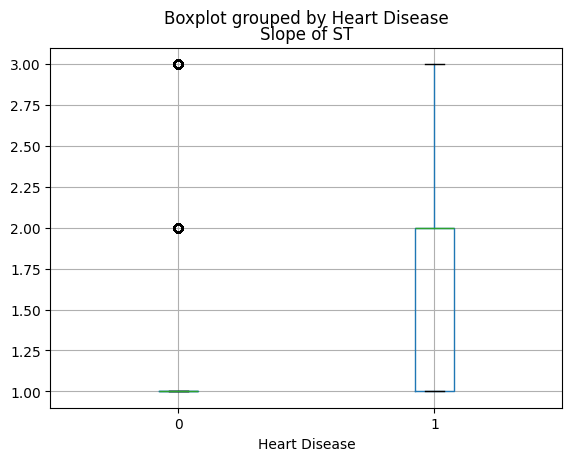

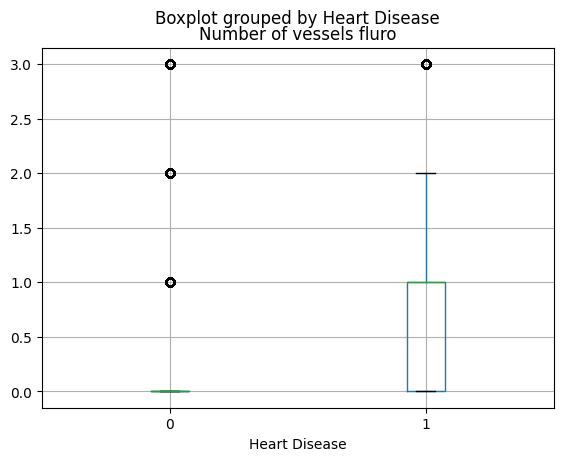

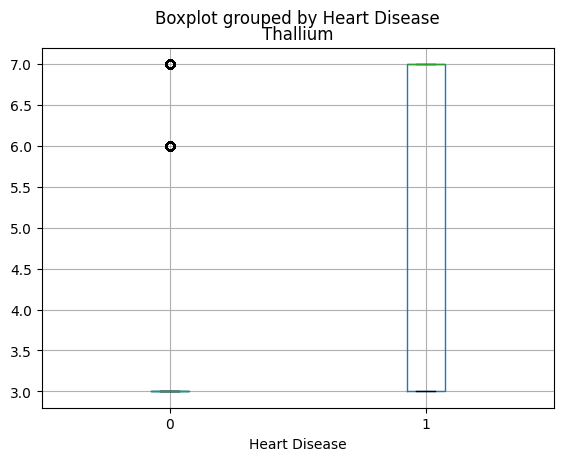

In [27]:
from matplotlib import pyplot as plt
for col in cols:
  train.boxplot(column=col, by='Heart Disease')
  plt.title(col)
  plt.show()

In [28]:
from sklearn.model_selection import train_test_split
X=train.drop(columns=['id','Heart Disease'],axis=1)
y=train['Heart Disease']

In [29]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)

In [30]:
from sklearn.preprocessing import RobustScaler
scaler=RobustScaler()
X_train=scaler.fit_transform(x_train)
X_test=scaler.transform(x_test)


In [31]:
from sklearn.linear_model import LogisticRegression
model_LR=LogisticRegression()
model_LR.fit(X_train,y_train)
y_prob=model_LR.predict_proba(X_test)[:,1]

In [32]:
from sklearn.metrics import roc_auc_score
aucLR=roc_auc_score(y_test,y_prob)
aucLR

np.float64(0.9502142508013594)

In [33]:
X_full=scaler.fit_transform(X)
X_test_full=scaler.transform(test.drop(['id'],axis=1))
model_LR.fit(X_full,y)
y_pred_test=model_LR.predict_proba(X_test_full)[:,1]

In [34]:
submission = pd.DataFrame({
    'id': test['id'],
    'Heart Disease': y_pred_test
})

submission.to_csv("submissionHeart.csv", index=False)


In [37]:
from sklearn.ensemble import RandomForestClassifier
model_RF=RandomForestClassifier( n_estimators=300,
    max_depth=10,
    random_state=42)
model_RF.fit(x_train,y_train)
y_prob_RF=model_RF.predict_proba(x_test)[:,1]
aucRF=roc_auc_score(y_test,y_prob_RF)
aucRF

np.float64(0.9520601739869433)

In [38]:
model_RF.fit(X,y)
y_pred_test_RF=model_RF.predict_proba(test.drop(['id'],axis=1))[:,1]
submission=pd.DataFrame({
    'id':test['id'],
    'Heart Disease':y_pred_test_RF
})
submission.to_csv('submissionHeartRF.csv',index=False)

In [39]:
from xgboost import XGBClassifier
model_XGB = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='auc'
)
model_XGB.fit(X,y)
y_pred_test_XGB=model_XGB.predict_proba(test.drop(['id'],axis=1))[:,1]
submission=pd.DataFrame({
    'id':test['id'],
    'Heart Disease':y_pred_test_XGB
})
submission.to_csv('submissionHeartXGB.csv',index=False)

In [41]:
model_XGB.fit(train.drop(['id','FBS over 120','Heart Disease'],axis=1),y)
y_pred_test_XGB=model_XGB.predict_proba(test.drop(['id','FBS over 120'],axis=1))[:,1]
submission=pd.DataFrame({
    'id':test['id'],
    'Heart Disease':y_pred_test_XGB
})
submission.to_csv('submissionHeartXGB2.csv',index=False)

In [42]:
model_XGB.fit(train.drop(['id','FBS over 120','BP','Heart Disease'],axis=1),y)
y_pred_test_XGB=model_XGB.predict_proba(test.drop(['id','FBS over 120','BP'],axis=1))[:,1]
submission=pd.DataFrame({
    'id':test['id'],
    'Heart Disease':y_pred_test_XGB
})
submission.to_csv('submissionHeartXGB3.csv',index=False)